# Mini End-to-End AI Project
## Heart Disease Prediction using Machine Learning

Dataset: Heart Disease UCI (CSV from Kaggle/UCI)

Upload `heart.csv` to Google Colab before running.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


## 2. Upload and Load Dataset

In [3]:
uploaded = files.upload()
df = pd.read_csv("heart-disease.csv")
df.head()

Saving heart-disease.csv to heart-disease (1).csv


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


## 3. Explore Dataset

In [4]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())

(303, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997 

## 4. Data Cleaning

In [5]:
df.drop_duplicates(inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)
print("Data cleaned")

Data cleaned


## 5. Visualization

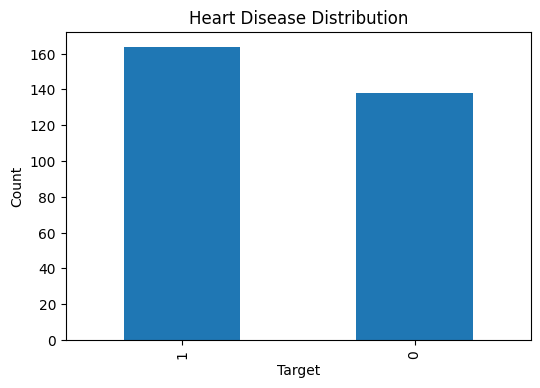

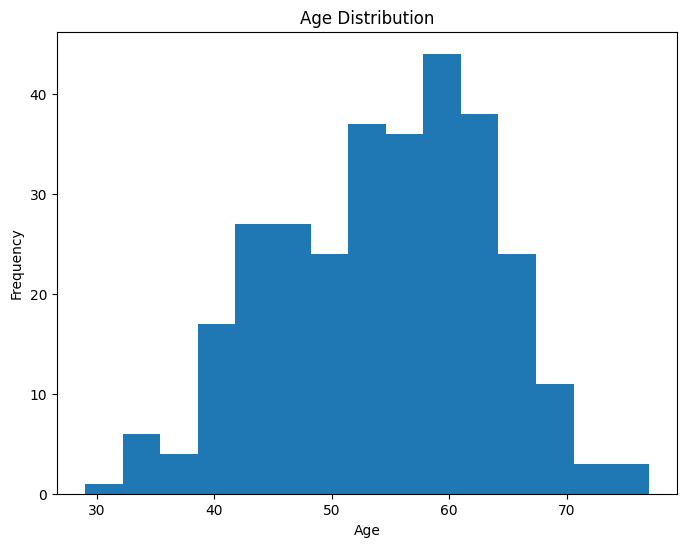

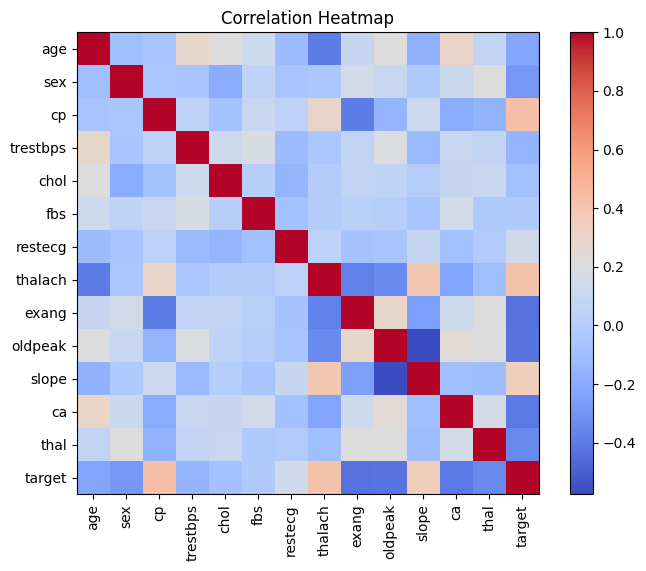

In [6]:
plt.figure(figsize=(6,4))
df["target"].value_counts().plot(kind="bar")
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,6))
plt.hist(df["age"], bins=15)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(df.corr(), cmap="coolwarm")
plt.colorbar()
plt.xticks(range(len(df.columns)), df.columns, rotation=90)
plt.yticks(range(len(df.columns)), df.columns)
plt.title("Correlation Heatmap")
plt.show()


## 6. Preprocessing

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X = scaler.fit_transform(X)


## 7. Train-Test Split

In [8]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42)
print(X_train.shape,X_test.shape)

(241, 13) (61, 13)


## 8. Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)

print("Accuracy:",accuracy_score(y_test,lr_pred))
print(classification_report(y_test,lr_pred))
print(confusion_matrix(y_test,lr_pred))


Accuracy: 0.819672131147541
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        29
           1       0.84      0.81      0.83        32

    accuracy                           0.82        61
   macro avg       0.82      0.82      0.82        61
weighted avg       0.82      0.82      0.82        61

[[24  5]
 [ 6 26]]


## 9. Random Forest

In [10]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)

print("Accuracy:",accuracy_score(y_test,rf_pred))
print(classification_report(y_test,rf_pred))
print(confusion_matrix(y_test,rf_pred))


Accuracy: 0.8688524590163934
              precision    recall  f1-score   support

           0       0.84      0.90      0.87        29
           1       0.90      0.84      0.87        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61

[[26  3]
 [ 5 27]]


## 10. Error Analysis

In [11]:
errors = pd.DataFrame({
    "Actual":y_test.values,
    "Predicted":rf_pred
})

wrong = errors[errors["Actual"]!=errors["Predicted"]]
print("Wrong Predictions:",len(wrong))
wrong.head()


Wrong Predictions: 8


,Actual,Predicted
2,1,0
11,1,0
20,1,0
22,0,1
25,0,1


## 11. Feature Importance

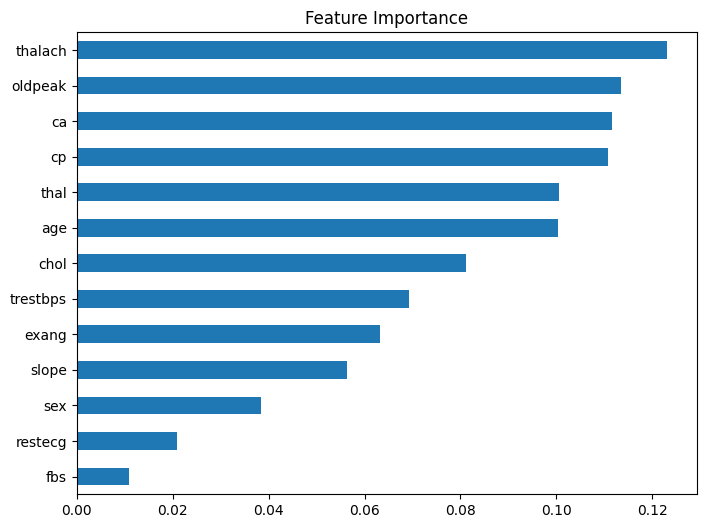

In [12]:
importance = pd.Series(rf.feature_importances_,
                        index=df.drop("target",axis=1).columns)
importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()


# Business Insights

- Older patients tend to have a higher risk of heart disease.
- Chest pain type and maximum heart rate are important predictors.
- Random Forest usually performs better than Logistic Regression.
- The model can help hospitals identify high-risk patients for early screening.

## Conclusion

A complete machine learning pipeline was implemented:
- Data Cleaning
- Visualization
- Preprocessing
- Model Training
- Evaluation
- Error Analysis
- Business Insights
